# Advanced Behavioral Biometric Feature Analysis (V2)

This notebook explores the extraction of advanced statistical and parametric features from Keystroke and Mouse Trajectory (KMT) data. The goal is to build a robust 'behavioral fingerprint' for user identification.

## 1. Data Loading and Initial Inspection

We load raw KMT data in JSON format for multiple users. Each dataset contains session details and behavioral logs for both the legitimate user and potential imposters.

In [78]:
import json
import os

# Define the path to the raw JSON directory relative to this notebook
raw_data_path = r'../data_raw/feature_kmt_dataset_Edge_Hill_University_22/feature_kmt_json'

# List of 3 files to load
files_to_load = [
    'raw_kmt_user_0001.json',
    'raw_kmt_user_0002.json',
    'raw_kmt_user_0003.json'
]

# Dictionary to hold the loaded JSON data
users_data = {}

# Load each file
for file_name in files_to_load:
    file_path = os.path.join(raw_data_path, file_name)
    with open(file_path, 'r') as f:
        data = json.load(f)
        users_data[file_name] = data
        print(f"Loaded {file_name} successfully. Primary keys: {list(data.keys())}")


Loaded raw_kmt_user_0001.json successfully. Primary keys: ['details', 'true_data', 'false_data']
Loaded raw_kmt_user_0002.json successfully. Primary keys: ['details', 'true_data', 'false_data']
Loaded raw_kmt_user_0003.json successfully. Primary keys: ['details', 'true_data', 'false_data']


## 2. Exploratory Data Analysis: Dwell Time Distributions

Dwell time (hold time) is a primary biometric indicator. Here we calculate timings from raw events and use Kernel Density Estimation (KDE) to visualize how these distributions vary between different users and sessions.

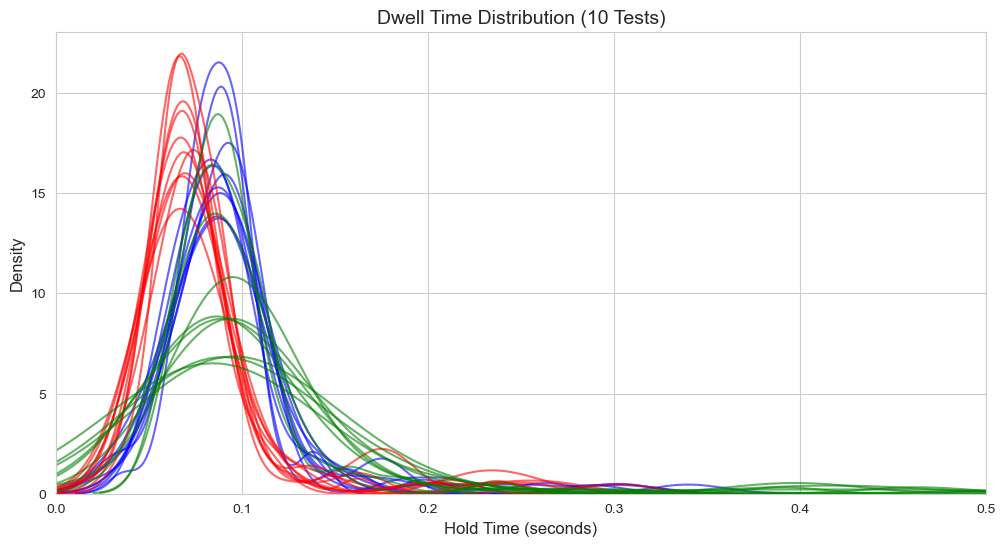

In [79]:
import json
import seaborn as sns
import matplotlib.pyplot as plt


true_data_user_01 = users_data['raw_kmt_user_0001.json']['true_data']
true_data_user_02 = users_data['raw_kmt_user_0002.json']['true_data']
true_data_user_03 = users_data['raw_kmt_user_0003.json']['true_data']

# 2. Function to calculate Dwell Time (Hold Time)
def calculate_dwell_times(events):
    last_press = {}
    dwell_times = []
    for event in events:
        key = event.get('Key')
        event_type = event.get('Event')
        try:
            epoch = float(event.get('Epoch'))
        except (ValueError, TypeError):
            continue
            
        if event_type == 'pressed':
            last_press[key] = epoch
        elif event_type == 'released':
            if key in last_press:
                # Dwell Time = T_release - T_press
                dwell_times.append(epoch - last_press[key])
                del last_press[key]
    return dwell_times

# 3. Setup the Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 4. Process and Plot each test as a line
# Using a consistent color for all 10 lines
line_color_user_01 = 'blue' 

for test_id in sorted(true_data_user_01.keys()):
    events = true_data_user_01[test_id].get('key_events', [])
    dwell_times = calculate_dwell_times(events)
    
    # Only plot if we have enough data points for a smooth line
    if len(dwell_times) > 1:
        sns.kdeplot(dwell_times, color=line_color_user_01, alpha=0.6, linewidth=1.5, label=test_id)

line_color_user_02 = 'red' 

for test_id in sorted(true_data_user_02.keys()):
    events = true_data_user_02[test_id].get('key_events', [])
    dwell_times = calculate_dwell_times(events)
    
    # Only plot if we have enough data points for a smooth line
    if len(dwell_times) > 1:
        sns.kdeplot(dwell_times, color=line_color_user_02, alpha=0.6, linewidth=1.5, label=test_id)


line_color_user_03 = 'green' 

for test_id in sorted(true_data_user_03.keys()):
    events = true_data_user_03[test_id].get('key_events', [])
    dwell_times = calculate_dwell_times(events)
    
    # Only plot if we have enough data points for a smooth line
    if len(dwell_times) > 1:
        sns.kdeplot(dwell_times, color=line_color_user_03, alpha=0.6, linewidth=1.5, label=test_id)


# 5. Final Formatting
plt.title('Dwell Time Distribution (10 Tests)', fontsize=14)
plt.xlabel('Hold Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 0.5) # Adjust this limit based on your data range
plt.show()

## 3. Advanced Feature Extraction Pipeline (V2)

The V2 pipeline enhances the feature set by applying:
- **IQR Outlier Filtering**: To remove noise from distractions.
- **Higher-order Statistics**: Capturing distribution shape via Skewness and Kurtosis.
- **Parametric Modeling**: Fitting a Gamma distribution to extract stable shape and scale parameters.

In [80]:
from sympy.parsing.sympy_parser import null
import numpy as np
from scipy import stats
from IPython.display import display
import pandas as pd

def extract_biometric_features(dwell_times):
    data = np.array(dwell_times)
    
    # 1. IQR Filtering to remove outliers
    if len(data) > 4:  # Need sufficient data to calculate quartiles meaningfully
        q1, q3 = np.percentile(data, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        
        # Keep only data within the "reasonable" human range
        # Also ensure we don't allow negative dwell times
        cleaned_data = data[(data >= max(0, lower_bound)) & (data <= upper_bound)]
    else:
        cleaned_data = data # Not enough data to filter, proceed as is

    # Fallback if cleaning leaves us with no data
    if len(cleaned_data) == 0:
        return {
            "mean": np.nan, "std": np.nan, "skew": np.nan,
            "kurtosis": np.nan, "gamma_shape": np.nan, "gamma_scale": np.nan
        }

    # 2. Calculate Stats on CLEANED data
    mean_val = np.mean(cleaned_data)
    std_dev = np.std(cleaned_data)
    skewness = stats.skew(cleaned_data)
    kurtosis = stats.kurtosis(cleaned_data)
    
    # 3. Parametric Fitting (Gamma) on CLEANED data
    try:
        # Fitting on cleaned data will produce much more stable shape/scale values
        shape, loc, scale = stats.gamma.fit(cleaned_data, floc=0) 
    except:
        shape, loc, scale = np.nan, np.nan, np.nan
        
    return {
        "mean": mean_val,
        "std": std_dev,
        "skew": skewness,
        "kurtosis": kurtosis,
        "gamma_shape": shape,
        "gamma_scale": scale
    }


def extracted_function(true_data_user_01, calculate_dwell_times, extract_biometric_features, all_test_features):
    # Loop through tests 1 to 10
    for i in range(1, 11):
        test_key = f'test_{i}' # Formats as 'test_1', 'test_2', ..., 'test_10'
    
        # Check if the test key exists in the user's data
        if test_key in true_data_user_01:
            events = true_data_user_01[test_key].get('key_events', [])
    
            # Calculate dwell times (assuming calculate_dwell_times is defined earlier in your notebook)
            dwell_times = calculate_dwell_times(events)
    
            # Extract features
            features = extract_biometric_features(dwell_times)
    
            # Add the test name to the dictionary so we can identify it in the DataFrame
            features['test_id'] = test_key
    
            # Append to our list
            all_test_features.append(features)
        else:
            print(f"Warning: {test_key} not found in the data.")

# Create an empty list to store the features for all tests
all_test_features_user_01 = []
all_test_features_user_02 = []
all_test_features_user_03 = []

extracted_function(true_data_user_01, calculate_dwell_times, extract_biometric_features, all_test_features_user_01)
extracted_function(true_data_user_02, calculate_dwell_times, extract_biometric_features, all_test_features_user_02)
extracted_function(true_data_user_03, calculate_dwell_times, extract_biometric_features, all_test_features_user_03)




# Convert the list of all test features into a single pandas DataFrame
def to_data_frame_to_display(all_test_features):
    df_features = pd.DataFrame(all_test_features)

    # Move 'test_id' to be the first column for better readability
    if not df_features.empty:
        cols = ['test_id'] + [col for col in df_features.columns if col != 'test_id']
        df_features = df_features[cols]

    return df_features

df_features_user_01 = to_data_frame_to_display(all_test_features_user_01)
df_features_user_02 = to_data_frame_to_display(all_test_features_user_02)
df_features_user_03 = to_data_frame_to_display(all_test_features_user_03)


# Display the final DataFrame containing all tests
print("User 01")
display(df_features_user_01)

print("User 02")
display(df_features_user_02)

print("User 03")
display(df_features_user_03)

User 01


,test_id,mean,std,skew,kurtosis,gamma_shape,gamma_scale
0,test_1,0.086414,0.016220,-0.049620,-0.940319,27.332493,0.003162
1,test_2,0.085432,0.013853,-0.231369,-0.665543,36.094959,0.002367
2,test_3,0.087346,0.017016,-0.272503,-0.387325,24.226644,0.003605
3,test_4,0.087753,0.015966,-0.524898,-0.538410,27.260723,0.003219
4,test_5,0.082297,0.017404,0.189877,-0.367492,21.852163,0.003766
5,test_6,0.083867,0.014898,-0.066401,-0.471046,30.292108,0.002769
6,test_7,0.086171,0.013198,-0.093089,-0.785274,41.259803,0.002088
7,test_8,0.086997,0.014895,-0.242027,-0.177354,31.846139,0.002732
8,test_9,0.085313,0.016768,-0.158629,-0.063723,24.042699,0.003548
9,test_10,0.087589,0.015151,-0.165292,0.121525,31.304305,0.002798


User 02


,test_id,mean,std,skew,kurtosis,gamma_shape,gamma_scale
0,test_1,0.071398,0.014607,-0.614503,0.419133,20.028953,0.003565
1,test_2,0.072321,0.015208,0.134649,0.016679,21.582247,0.003351
2,test_3,0.067845,0.011095,0.038093,-0.570819,36.481668,0.001860
3,test_4,0.067155,0.009243,0.256988,-0.197287,52.795247,0.001272
4,test_5,0.069014,0.011645,0.077453,-0.968121,34.549483,0.001998
5,test_6,0.068447,0.008689,-0.084852,-0.457639,60.461276,0.001132
6,test_7,0.067350,0.010666,0.129878,-0.597142,39.382608,0.001710
7,test_8,0.067759,0.011089,0.169574,-0.559190,36.966916,0.001833
8,test_9,0.068784,0.010978,-0.166460,-0.688769,37.549721,0.001832
9,test_10,0.066751,0.008215,0.832785,0.816764,69.114212,0.000966


User 03


,test_id,mean,std,skew,kurtosis,gamma_shape,gamma_scale
0,test_1,0.097743,0.018055,0.904174,0.430725,31.498959,0.003103
1,test_2,0.098497,0.026710,0.704041,-0.171207,14.369917,0.006854
2,test_3,0.087363,0.016604,0.088348,-1.091334,27.189240,0.003213
3,test_4,0.086329,0.015487,0.438003,0.740114,31.011190,0.002784
4,test_5,0.087043,0.014567,0.324742,0.356080,35.605942,0.002445
5,test_6,0.086688,0.015140,0.301472,-0.453331,32.891169,0.002636
6,test_7,0.092507,0.023475,1.250193,0.956118,17.848311,0.005183
7,test_8,0.095000,0.021703,0.332292,-0.399321,19.079414,0.004979
8,test_9,0.090582,0.017371,0.619535,-0.384314,28.376101,0.003192
9,test_10,0.084786,0.013752,0.775603,0.294564,40.097987,0.002114


## 4 colparition the varible with orginal data

In [81]:
import numpy as np
from scipy.stats import gamma

# Helper to get average parameters for a user
def get_average_gamma_params(features_list):
    # Filter out NaNs to ensure the average is accurate
    valid_shapes = [f['gamma_shape'] for f in features_list if not np.isnan(f['gamma_shape'])]
    valid_scales = [f['gamma_scale'] for f in features_list if not np.isnan(f['gamma_scale'])]
    
    return np.mean(valid_shapes), np.mean(valid_scales)

# Calculate for all three users
avg_shape_1, avg_scale_1 = get_average_gamma_params(all_test_features_user_01)
avg_shape_2, avg_scale_2 = get_average_gamma_params(all_test_features_user_02)
avg_shape_3, avg_scale_3 = get_average_gamma_params(all_test_features_user_03)

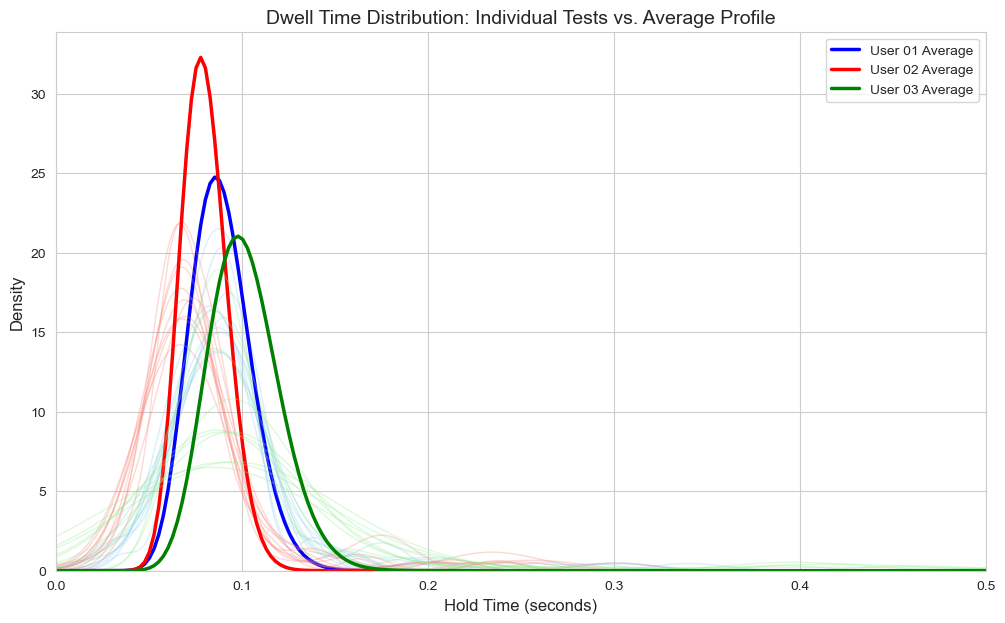

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Define users, their data, and their specific colors
users_config = [
    {'data': true_data_user_01, 'shape': avg_shape_1, 'scale': avg_scale_1, 'light': 'skyblue', 'dark': 'blue', 'label': 'User 01'},
    {'data': true_data_user_02, 'shape': avg_shape_2, 'scale': avg_scale_2, 'light': 'salmon', 'dark': 'red', 'label': 'User 02'},
    {'data': true_data_user_03, 'shape': avg_shape_3, 'scale': avg_scale_3, 'light': 'lightgreen', 'dark': 'green', 'label': 'User 03'},
]

x = np.linspace(0, 0.5, 200) # Range for dwell time

for config in users_config:
    # A. Plot Light Distributions (Individual Tests)
    for test_id in sorted(config['data'].keys()):
        events = config['data'][test_id].get('key_events', [])
        dwell_times = calculate_dwell_times(events)
        if len(dwell_times) > 1:
            sns.kdeplot(dwell_times, color=config['light'], alpha=0.3, linewidth=1)
            
    # B. Plot Dark Average Line (Calculated Gamma PDF)
    # Using the averaged parameters computed above
    y_avg = gamma.pdf(x, a=config['shape'], loc=0, scale=config['scale'])
    plt.plot(x, y_avg, color=config['dark'], linewidth=2.5, label=f'{config["label"]} Average')

plt.title('Dwell Time Distribution: Individual Tests vs. Average Profile', fontsize=14)
plt.xlabel('Hold Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 0.5)
plt.legend()
plt.show()

## 5.

## 5. Advanced Feature Extraction Pipeline (Authentication-Ready)

Here we move from simple descriptive statistics to an authentication-ready schema. We extract advanced features including gamma distribution parameters, moments, Shannon entropy, and digraph profiles.

In [83]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import math

def extract_advanced_features(dwell_times, events):
    """
    Extract advanced features from dwell times and events.
    """
    features = {}
    
    # 1. Gamma params
    if len(dwell_times) > 0:
        shape, loc, scale = stats.gamma.fit(dwell_times, floc=0)
        features["gamma_params"] = {"shape": shape, "scale": scale}
    else:
        features["gamma_params"] = {"shape": 0.0, "scale": 0.0}
        
    # 2. Moments
    if len(dwell_times) > 0:
        features["moments"] = {
            "mean": float(np.mean(dwell_times)),
            "std": float(np.std(dwell_times)),
            "skew": float(stats.skew(dwell_times)) if len(dwell_times) > 2 else 0.0,
            "kurtosis": float(stats.kurtosis(dwell_times)) if len(dwell_times) > 3 else 0.0
        }
    else:
        features["moments"] = {"mean": 0.0, "std": 0.0, "skew": 0.0, "kurtosis": 0.0}
        
    # 3. n_samples
    features["n_samples"] = len(dwell_times)
    
    # 4. timestamp (unix epoch) - from first event if available
    if events:
        try:
            ts = float(events[0].get('Epoch', 0))
        except (ValueError, TypeError):
            ts = 0.0
        features["timestamp"] = ts
    else:
        features["timestamp"] = 0.0
    
    # 5. entropy
    if len(dwell_times) > 0:
        # Calculate Shannon entropy using a histogram approach
        counts, _ = np.histogram(dwell_times, bins='auto')
        probs = counts / counts.sum()
        entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)
        features["entropy"] = float(entropy)
    else:
        features["entropy"] = 0.0
        
    # 6. digraph_profile
    digraph_profile = {}
    if len(events) >= 2:
        digraphs = {}
        for i in range(len(events) - 1):
            if events[i].get('Event') == 'pressed' and events[i+1].get('Event') == 'pressed':
                key1 = events[i].get('Key', '')
                key2 = events[i+1].get('Key', '')
                try:
                    epoch1 = float(events[i].get('Epoch', 0))
                    epoch2 = float(events[i+1].get('Epoch', 0))
                except (ValueError, TypeError):
                    continue
                    
                if key1 and key2:
                    pair = f"{key1}-{key2}"
                    latency = epoch2 - epoch1
                    if pair not in digraphs:
                        digraphs[pair] = []
                    digraphs[pair].append(latency)
        
        # Calculate averages for each pair
        avg_digraphs = {pair: np.mean(latencies) for pair, latencies in digraphs.items()}
        # Get top 5 most common pairs based on frequency
        sorted_pairs = sorted(digraphs.keys(), key=lambda k: len(digraphs[k]), reverse=True)[:5]
        digraph_profile = {pair: float(avg_digraphs[pair]) for pair in sorted_pairs}
        
    features["digraph_profile"] = digraph_profile
    
    return features

In [84]:
# Process all test files for 3 users into a list of dictionaries following the schema above.
processed_data = []

def get_dwell_times(events):
    last_press = {}
    dwell_times = []
    for event in events:
        key = event.get('Key')
        event_type = event.get('Event')
        try:
            epoch = float(event.get('Epoch'))
        except (ValueError, TypeError):
            continue
            
        if event_type == 'pressed':
            last_press[key] = epoch
        elif event_type == 'released':
            if key in last_press:
                dwell = epoch - last_press[key]
                if 0 < dwell < 5: # filter out anomalies (seconds)
                    dwell_times.append(dwell)
                del last_press[key]
    return dwell_times

for user_id, data in users_data.items():
    # Process true_data
    for session_idx, session in data.get('true_data', {}).items():
        events = session.get('key_events', [])
        dwell_times = get_dwell_times(events)
        
        features = extract_advanced_features(dwell_times, events)
        features['user'] = user_id
        features['label'] = 1 # Legitimate
        features['session'] = session_idx
        processed_data.append(features)
        
    # Process false_data
    for session_idx, session in data.get('false_data', {}).items():
        events = session.get('key_events', [])
        dwell_times = get_dwell_times(events)
                    
        features = extract_advanced_features(dwell_times, events)
        features['user'] = user_id
        features['label'] = 0 # Imposter
        features['session'] = session_idx
        processed_data.append(features)

# Convert these lists into a flattened pandas DataFrame
flattened_data = []
for row in processed_data:
    flat_row = {
        'user': row['user'],
        'label': row['label'],
        'session': row['session'],
        'gamma_shape': row['gamma_params']['shape'],
        'gamma_scale': row['gamma_params']['scale'],
        'moment_mean': row['moments']['mean'],
        'moment_std': row['moments']['std'],
        'moment_skew': row['moments']['skew'],
        'moment_kurtosis': row['moments']['kurtosis'],
        'n_samples': row['n_samples'],
        'timestamp': row['timestamp'],
        'entropy': row['entropy']
    }
    # Add digraphs
    for i, (pair, latency) in enumerate(row['digraph_profile'].items()):
        flat_row[f'digraph_{i+1}_pair'] = pair
        flat_row[f'digraph_{i+1}_latency'] = latency
        
    flattened_data.append(flat_row)

df_advanced_features = pd.DataFrame(flattened_data)
display(df_advanced_features.head())

C:\Users\Ravin\AppData\Local\Temp\ipykernel_19696\1791435163.py:48: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)


,user,label,session,gamma_shape,gamma_scale,moment_mean,moment_std,moment_skew,moment_kurtosis,n_samples,...,digraph_1_pair,digraph_1_latency,digraph_2_pair,digraph_2_latency,digraph_3_pair,digraph_3_latency,digraph_4_pair,digraph_4_latency,digraph_5_pair,digraph_5_latency
0,raw_kmt_user_0001.json,1,test_1,9.506793,0.009818,0.093341,0.036234,3.078586,13.251395,57,...,shift-m,0.094777,spacebar-shift,0.073022,w-e,0.000000,shift-e,0.176325,l-i,0.125325
1,raw_kmt_user_0001.json,1,test_2,11.734102,0.007249,0.085055,0.023216,0.384579,2.474012,50,...,shift-m,0.081046,shift-e,0.062469,l-i,0.049065,i-e,0.086411,8-9,0.049091
2,raw_kmt_user_0001.json,1,test_3,9.157411,0.009974,0.091337,0.029751,0.900688,1.988247,50,...,shift-m,0.081669,shift-e,0.076365,l-i,0.124784,l-e,0.049181,8-9,0.063076
3,raw_kmt_user_0001.json,1,test_4,10.260792,0.008907,0.091395,0.029832,1.830122,6.366527,44,...,shift-m,0.108630,shift-e,0.086512,l-i,0.076167,l-e,0.076149,8-9,0.061542
4,raw_kmt_user_0001.json,1,test_5,12.758214,0.006866,0.087598,0.026871,1.779152,4.793167,45,...,shift-m,0.106731,shift-e,0.037032,l-i,0.098616,spacebar-m,0.061413,l-e,0.061384


C:\Users\Ravin\AppData\Local\Temp\ipykernel_19696\1791435163.py:48: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)


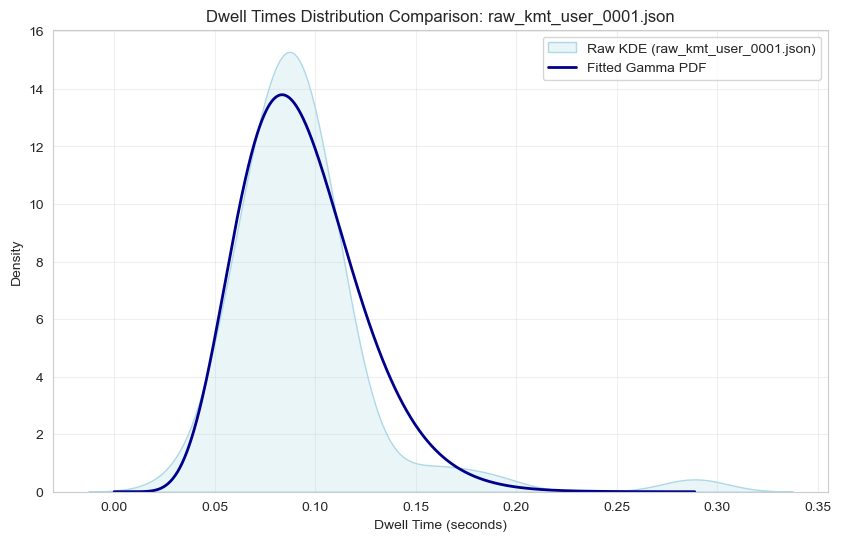

C:\Users\Ravin\AppData\Local\Temp\ipykernel_19696\1791435163.py:48: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)


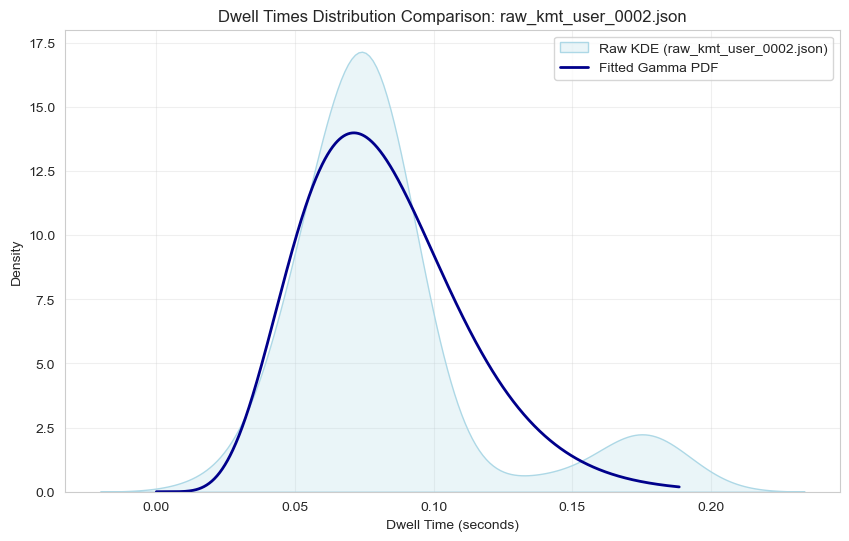

C:\Users\Ravin\AppData\Local\Temp\ipykernel_19696\1791435163.py:48: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)


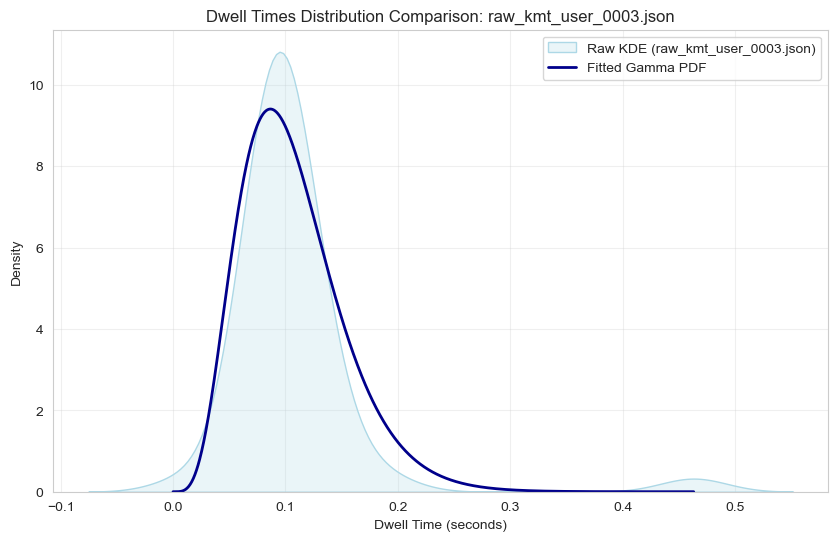

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_comparison(dwell_times, features, user_label):
    """
    Plots a comparison of raw dwell times KDE and fitted Gamma PDF.
    """
    plt.figure(figsize=(10, 6))
    
    # a) Light-colored KDE plot of original raw dwell_times
    if len(dwell_times) > 1:
        sns.kdeplot(dwell_times, color='lightblue', fill=True, label=f'Raw KDE ({user_label})')
    
    # b) Dark-colored line plot (using scipy.stats.gamma.pdf)
    shape = features['gamma_params']['shape']
    scale = features['gamma_params']['scale']
    
    x = np.linspace(0, max(dwell_times) if dwell_times else 0.5, 1000)
    if shape > 0 and scale > 0:
        pdf_fitted = stats.gamma.pdf(x, a=shape, scale=scale)
        plt.plot(x, pdf_fitted, color='darkblue', linewidth=2, label='Fitted Gamma PDF')
    
    plt.title(f'Dwell Times Distribution Comparison: {user_label}')
    plt.xlabel('Dwell Time (seconds)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot a comparison for the first session of each user
for user_id in users_data.keys():
    first_session_key = list(users_data[user_id]['true_data'].keys())[0]
    session_events = users_data[user_id]['true_data'][first_session_key].get('key_events', [])
    
    dwell_times = get_dwell_times(session_events)
    features = extract_advanced_features(dwell_times, session_events)
    plot_comparison(dwell_times, features, user_id)


## 6. Privacy-Preserving Numerical Transformation

In behavioral authentication, logging the actual keys typed (like `shift-m`) is considered highly sensitive and acts like a privacy-invasive keylogger. To build a secure and privacy-preserving machine learning model, we will:
1. Drop the explicit keystroke combinations (`digraph_X_pair`) and only keep the behavioral timings (`digraph_X_latency`).
2. Map the string identifiers for `user` and `session` to clean integer IDs.

In [86]:
# Create a copy to preserve the original dataframe
df_clean = df_advanced_features.copy()

# 1. Drop sensitive keystroke pair strings
pair_columns = [col for col in df_clean.columns if 'pair' in col]
df_clean = df_clean.drop(columns=pair_columns)

# 2. Convert 'user' strings to numerical IDs (e.g., 'raw_kmt_user_0001.json' -> 1)
df_clean['user'] = df_clean['user'].str.extract(r'(\d+)').astype(int)

# 3. Convert 'session' strings to numerical IDs (e.g., 'test_1' -> 1)
df_clean['session'] = df_clean['session'].str.extract(r'(\d+)').astype(int)

# 4. Convert label to int (just in case)
df_clean['label'] = df_clean['label'].astype(int)

display(df_clean.head())
print("\nDataset Information:")
display(df_clean.info())


,user,label,session,gamma_shape,gamma_scale,moment_mean,moment_std,moment_skew,moment_kurtosis,n_samples,timestamp,entropy,digraph_1_latency,digraph_2_latency,digraph_3_latency,digraph_4_latency,digraph_5_latency
0,1,1,1,9.506793,0.009818,0.093341,0.036234,3.078586,13.251395,57,1.644174e+09,2.847763,0.094777,0.073022,0.000000,0.176325,0.125325
1,1,1,2,11.734102,0.007249,0.085055,0.023216,0.384579,2.474012,50,1.644174e+09,2.619067,0.081046,0.062469,0.049065,0.086411,0.049091
2,1,1,3,9.157411,0.009974,0.091337,0.029751,0.900688,1.988247,50,1.644174e+09,2.719538,0.081669,0.076365,0.124784,0.049181,0.063076
3,1,1,4,10.260792,0.008907,0.091395,0.029832,1.830122,6.366527,44,1.644174e+09,2.584974,0.108630,0.086512,0.076167,0.076149,0.061542
4,1,1,5,12.758214,0.006866,0.087598,0.026871,1.779152,4.793167,45,1.644174e+09,2.562721,0.106731,0.037032,0.098616,0.061413,0.061384



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user               60 non-null     int32  
 1   label              60 non-null     int32  
 2   session            60 non-null     int32  
 3   gamma_shape        60 non-null     float64
 4   gamma_scale        60 non-null     float64
 5   moment_mean        60 non-null     float64
 6   moment_std         60 non-null     float64
 7   moment_skew        60 non-null     float64
 8   moment_kurtosis    60 non-null     float64
 9   n_samples          60 non-null     int64  
 10  timestamp          60 non-null     float64
 11  entropy            60 non-null     float64
 12  digraph_1_latency  58 non-null     float64
 13  digraph_2_latency  58 non-null     float64
 14  digraph_3_latency  52 non-null     float64
 15  digraph_4_latency  38 non-null     float64
 16  digrap

None

## 7. Comparative Distribution: Raw Tests vs. Extracted Gamma PDF

Here we visualize how closely our extracted statistical features match the real-world data. We plot the individual test KDEs as faint lines, and we draw the bold lines using the mathematical **Gamma PDF** derived by averaging the `gamma_shape` and `gamma_scale` extracted in our DataFrame.

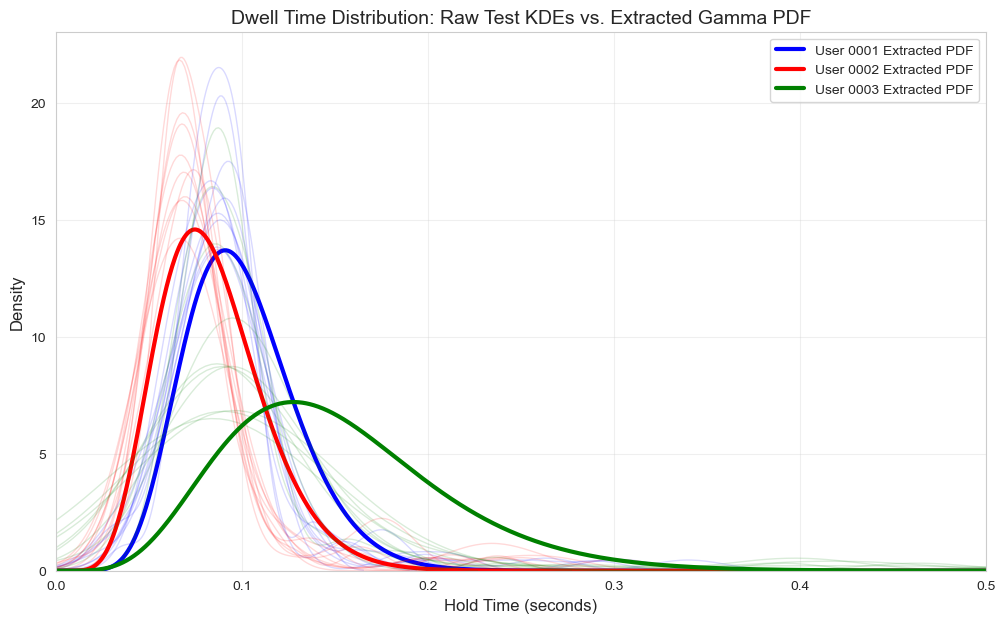

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

colors = ['blue', 'red', 'green']

# Loop through each user and plot
for i, (user_id, data) in enumerate(users_data.items()):
    color = colors[i % len(colors)]
    
    # 1. Plot individual test KDE (faint lines)
    for session_idx, session in data.get('true_data', {}).items():
        events = session.get('key_events', [])
        dwell_times = get_dwell_times(events)
        
        if len(dwell_times) > 1:
            sns.kdeplot(dwell_times, color=color, alpha=0.15, linewidth=1)
            
    # 2. Plot the extracted Gamma PDF (bold line) from our dataframe features
    # Filter the dataframe for this user's true_data (label == 1)
    user_df = df_advanced_features[(df_advanced_features['user'] == user_id) & (df_advanced_features['label'] == 1)]
    
    if not user_df.empty:
        # Average the extracted Gamma parameters
        avg_shape = user_df['gamma_shape'].mean()
        avg_scale = user_df['gamma_scale'].mean()
        
        # Draw the PDF
        x = np.linspace(0, 0.5, 1000)
        if avg_shape > 0 and avg_scale > 0:
            pdf_fitted = stats.gamma.pdf(x, a=avg_shape, scale=avg_scale)
            
            # Format user label
            import re
            match = re.search(r'(\d+)', user_id)
            user_num = match.group(1) if match else str(i+1)
            
            plt.plot(x, pdf_fitted, color=color, linewidth=3, label=f'User {user_num} Extracted PDF')

plt.title('Dwell Time Distribution: Raw Test KDEs vs. Extracted Gamma PDF', fontsize=14)
plt.xlabel('Hold Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. The Final Robust Pipeline (V3)

Having identified the vulnerability of our parametric models to outliers (like User 3's distractions), we now combine everything into the final, robust pipeline.

Key improvements in this final pass:
1. **IQR Outlier Filtering:** We dynamically filter out extreme dwell times (Q3 + 1.5*IQR) for each session before fitting the Gamma distribution.
2. **Privacy-Preservation:** We immediately drop sensitive string features (like specific keystrokes) and generate a strictly numerical, 17-column DataFrame.
3. **Verification Plot:** We re-plot the KDEs vs. Extracted Gamma PDFs to demonstrate how removing outliers fixes User 3's skewed distribution.


Final Privacy-Preserving Dataset:


C:\Users\Ravin\AppData\Local\Temp\ipykernel_19696\3638841235.py:48: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)


,user,label,session,gamma_shape,gamma_scale,moment_mean,moment_std,moment_skew,moment_kurtosis,n_samples,timestamp,entropy,digraph_1_latency,digraph_2_latency,digraph_3_latency,digraph_4_latency,digraph_5_latency
0,1,1,1,21.445185,0.003985,0.085463,0.017466,-0.328052,-0.281709,53,1.644174e+09,2.323039,0.094777,0.073022,0.000000,0.176325,0.125325
1,1,1,2,14.426824,0.005693,0.082130,0.018595,-1.043213,1.156929,48,1.644174e+09,2.354183,0.081046,0.062469,0.049065,0.086411,0.049091
2,1,1,3,13.225596,0.006417,0.084864,0.020361,-0.784331,0.666477,46,1.644174e+09,2.576847,0.081669,0.076365,0.124784,0.049181,0.063076
3,1,1,4,16.299128,0.005292,0.086250,0.018478,-1.035106,1.205044,42,1.644174e+09,2.359978,0.108630,0.086512,0.076167,0.076149,0.061542
4,1,1,5,21.852163,0.003766,0.082297,0.017404,0.189877,-0.367492,42,1.644174e+09,2.433114,0.106731,0.037032,0.098616,0.061413,0.061384


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user               60 non-null     int32  
 1   label              60 non-null     int32  
 2   session            60 non-null     int32  
 3   gamma_shape        60 non-null     float64
 4   gamma_scale        60 non-null     float64
 5   moment_mean        60 non-null     float64
 6   moment_std         60 non-null     float64
 7   moment_skew        60 non-null     float64
 8   moment_kurtosis    60 non-null     float64
 9   n_samples          60 non-null     int64  
 10  timestamp          60 non-null     float64
 11  entropy            60 non-null     float64
 12  digraph_1_latency  58 non-null     float64
 13  digraph_2_latency  58 non-null     float64
 14  digraph_3_latency  52 non-null     float64
 15  digraph_4_latency  38 non-null     float64
 16  digraph_5_latency  27 non-nu

None

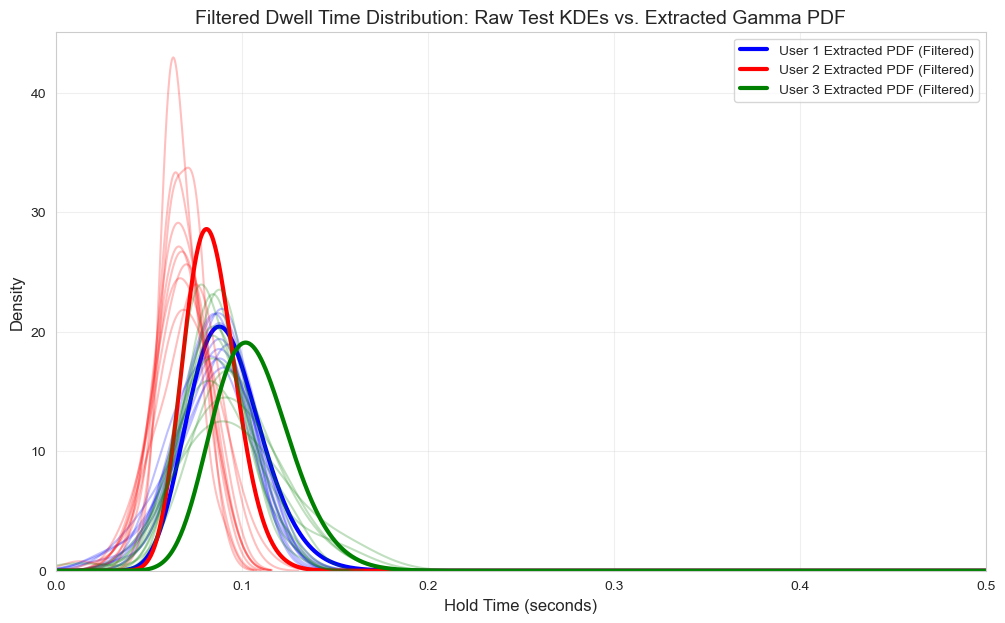

In [88]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import math
import re

# --- 1. Advanced Feature Extraction ---
def extract_advanced_features_v3(dwell_times, events):
    features = {}
    
    # 1. Gamma params
    if len(dwell_times) > 0:
        shape, loc, scale = stats.gamma.fit(dwell_times, floc=0)
        features["gamma_params"] = {"shape": shape, "scale": scale}
    else:
        features["gamma_params"] = {"shape": 0.0, "scale": 0.0}
        
    # 2. Moments
    if len(dwell_times) > 0:
        features["moments"] = {
            "mean": float(np.mean(dwell_times)),
            "std": float(np.std(dwell_times)),
            "skew": float(stats.skew(dwell_times)) if len(dwell_times) > 2 else 0.0,
            "kurtosis": float(stats.kurtosis(dwell_times)) if len(dwell_times) > 3 else 0.0
        }
    else:
        features["moments"] = {"mean": 0.0, "std": 0.0, "skew": 0.0, "kurtosis": 0.0}
        
    # 3. n_samples
    features["n_samples"] = len(dwell_times)
    
    # 4. timestamp (unix epoch)
    if events:
        try:
            ts = float(events[0].get('Epoch', 0))
        except (ValueError, TypeError):
            ts = 0.0
        features["timestamp"] = ts
    else:
        features["timestamp"] = 0.0
    
    # 5. entropy
    if len(dwell_times) > 0:
        counts, _ = np.histogram(dwell_times, bins='auto')
        probs = counts / counts.sum()
        entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)
        features["entropy"] = float(entropy)
    else:
        features["entropy"] = 0.0
        
    # 6. digraph_profile (Privacy Preserving - Latency Only)
    digraph_latencies = []
    if len(events) >= 2:
        digraphs = {}
        for i in range(len(events) - 1):
            if events[i].get('Event') == 'pressed' and events[i+1].get('Event') == 'pressed':
                key1 = events[i].get('Key', '')
                key2 = events[i+1].get('Key', '')
                try:
                    epoch1 = float(events[i].get('Epoch', 0))
                    epoch2 = float(events[i+1].get('Epoch', 0))
                except (ValueError, TypeError):
                    continue
                    
                if key1 and key2:
                    pair = f"{key1}-{key2}"
                    latency = epoch2 - epoch1
                    if pair not in digraphs:
                        digraphs[pair] = []
                    digraphs[pair].append(latency)
        
        avg_digraphs = {pair: np.mean(latencies) for pair, latencies in digraphs.items()}
        sorted_pairs = sorted(digraphs.keys(), key=lambda k: len(digraphs[k]), reverse=True)[:5]
        digraph_latencies = [float(avg_digraphs[pair]) for pair in sorted_pairs]
        
    features["digraph_latencies"] = digraph_latencies
    return features


# --- 2. Dwell Time Parsing with IQR Filtering ---
def get_filtered_dwell_times(events):
    last_press = {}
    raw_dwell_times = []
    for event in events:
        key = event.get('Key')
        event_type = event.get('Event')
        try:
            epoch = float(event.get('Epoch'))
        except (ValueError, TypeError):
            continue
            
        if event_type == 'pressed':
            last_press[key] = epoch
        elif event_type == 'released':
            if key in last_press:
                dwell = epoch - last_press[key]
                if 0 < dwell < 5: # Basic sanity filter
                    raw_dwell_times.append(dwell)
                del last_press[key]
                
    # Apply IQR Outlier Filtering
    if len(raw_dwell_times) > 4:
        q1 = np.percentile(raw_dwell_times, 25)
        q3 = np.percentile(raw_dwell_times, 75)
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr
        
        filtered_dwell_times = [d for d in raw_dwell_times if d <= upper_bound]
        return filtered_dwell_times
    
    return raw_dwell_times

# --- 3. Run Pipeline ---
processed_data_v3 = []

# To store filtered dwell times for plotting later
filtered_dwell_times_dict = {}

for user_id, data in users_data.items():
    filtered_dwell_times_dict[user_id] = {}
    
    # Process true_data
    for session_idx, session in data.get('true_data', {}).items():
        events = session.get('key_events', [])
        dwell_times = get_filtered_dwell_times(events)
        
        # Save for plotting
        filtered_dwell_times_dict[user_id][session_idx] = dwell_times
        
        features = extract_advanced_features_v3(dwell_times, events)
        features['user'] = user_id
        features['label'] = 1
        features['session'] = session_idx
        processed_data_v3.append(features)
        
    # Process false_data
    for session_idx, session in data.get('false_data', {}).items():
        events = session.get('key_events', [])
        dwell_times = get_filtered_dwell_times(events)
        
        features = extract_advanced_features_v3(dwell_times, events)
        features['user'] = user_id
        features['label'] = 0
        features['session'] = session_idx
        processed_data_v3.append(features)

# Convert to DataFrame
flattened_data_v3 = []
for row in processed_data_v3:
    flat_row = {
        'user': row['user'],
        'label': row['label'],
        'session': row['session'],
        'gamma_shape': row['gamma_params']['shape'],
        'gamma_scale': row['gamma_params']['scale'],
        'moment_mean': row['moments']['mean'],
        'moment_std': row['moments']['std'],
        'moment_skew': row['moments']['skew'],
        'moment_kurtosis': row['moments']['kurtosis'],
        'n_samples': row['n_samples'],
        'timestamp': row['timestamp'],
        'entropy': row['entropy']
    }
    
    # Add privacy-preserving digraph latencies
    for i in range(5):
        val = row['digraph_latencies'][i] if i < len(row['digraph_latencies']) else np.nan
        flat_row[f'digraph_{i+1}_latency'] = val
        
    flattened_data_v3.append(flat_row)

df_final = pd.DataFrame(flattened_data_v3)

# Map strings to integers
df_final['user'] = df_final['user'].str.extract(r'(\d+)').astype(int)
df_final['session'] = df_final['session'].str.extract(r'(\d+)').astype(int)
df_final['label'] = df_final['label'].astype(int)

print("\nFinal Privacy-Preserving Dataset:")
display(df_final.head())
display(df_final.info())

# --- 4. Plot Comparison (Filtered) ---
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
colors = ['blue', 'red', 'green']

for i, (user_id, sessions_dict) in enumerate(filtered_dwell_times_dict.items()):
    color = colors[i % len(colors)]
    
    # 1. Faint KDEs
    for session_idx, dwell_times in sessions_dict.items():
        if len(dwell_times) > 1:
            sns.kdeplot(dwell_times, color=color, alpha=0.25, linewidth=1.5, bw_adjust=1.5)
            
    # 2. Bold PDF
    user_num = int(re.search(r'(\d+)', user_id).group(1))
    user_df = df_final[(df_final['user'] == user_num) & (df_final['label'] == 1)]
    
    if not user_df.empty:
        avg_shape = user_df['gamma_shape'].mean()
        avg_scale = user_df['gamma_scale'].mean()
        
        x = np.linspace(0, 0.5, 1000)
        if avg_shape > 0 and avg_scale > 0:
            pdf_fitted = stats.gamma.pdf(x, a=avg_shape, scale=avg_scale)
            plt.plot(x, pdf_fitted, color=color, linewidth=3, label=f'User {user_num} Extracted PDF (Filtered)')

plt.title('Filtered Dwell Time Distribution: Raw Test KDEs vs. Extracted Gamma PDF', fontsize=14)
plt.xlabel('Hold Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
